# Chapter 66 — Function Transformations

> **Prerequisites:** ch056 (Visualization), ch058–060 (Function families)
>
> **You will learn:**
> - Apply vertical and horizontal shifts, stretches, and reflections
> - Compose multiple transformations in the correct order
> - Understand transformations as changes to input or output
> - Connect to data normalization and feature scaling
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **function transformation** modifies a known function by changing how inputs or outputs are processed before/after the function is applied.

Given a base function f(x), the family of transformations:
- **Vertical shift:** f(x) + k — adds k to every output
- **Horizontal shift:** f(x - h) — shifts graph right by h (left if h < 0)
- **Vertical stretch:** a·f(x) — multiplies every output by a
- **Horizontal stretch:** f(x/b) — stretches graph horizontally by factor b
- **Reflections:** -f(x) (flip vertical), f(-x) (flip horizontal)

**Key insight:** Transformations to the input (inside the function) behave *oppositely* to what you expect:
- f(x - 3) shifts *right* by 3 (not left)
- f(2x) compresses *horizontally* (not stretches)

This counter-intuitive behavior is because you're changing what input value produces the same output — it's a re-parameterization of the domain.

---

## 2. Intuition & Mental Models

**Physical analogy:** Adjusting a camera. Zoom (horizontal stretch) changes how much of the scene is captured. Brightness (vertical stretch) amplifies all pixel values. Pan (shift) moves the field of view.

**Computational analogy:** Data normalization is a function transformation. Standardization transforms f(x) to (f(x) - μ)/σ — a vertical shift and stretch. Min-max scaling is similar. The transformation is applied to *outputs*, not the underlying function structure.

---

## 3. Visualization

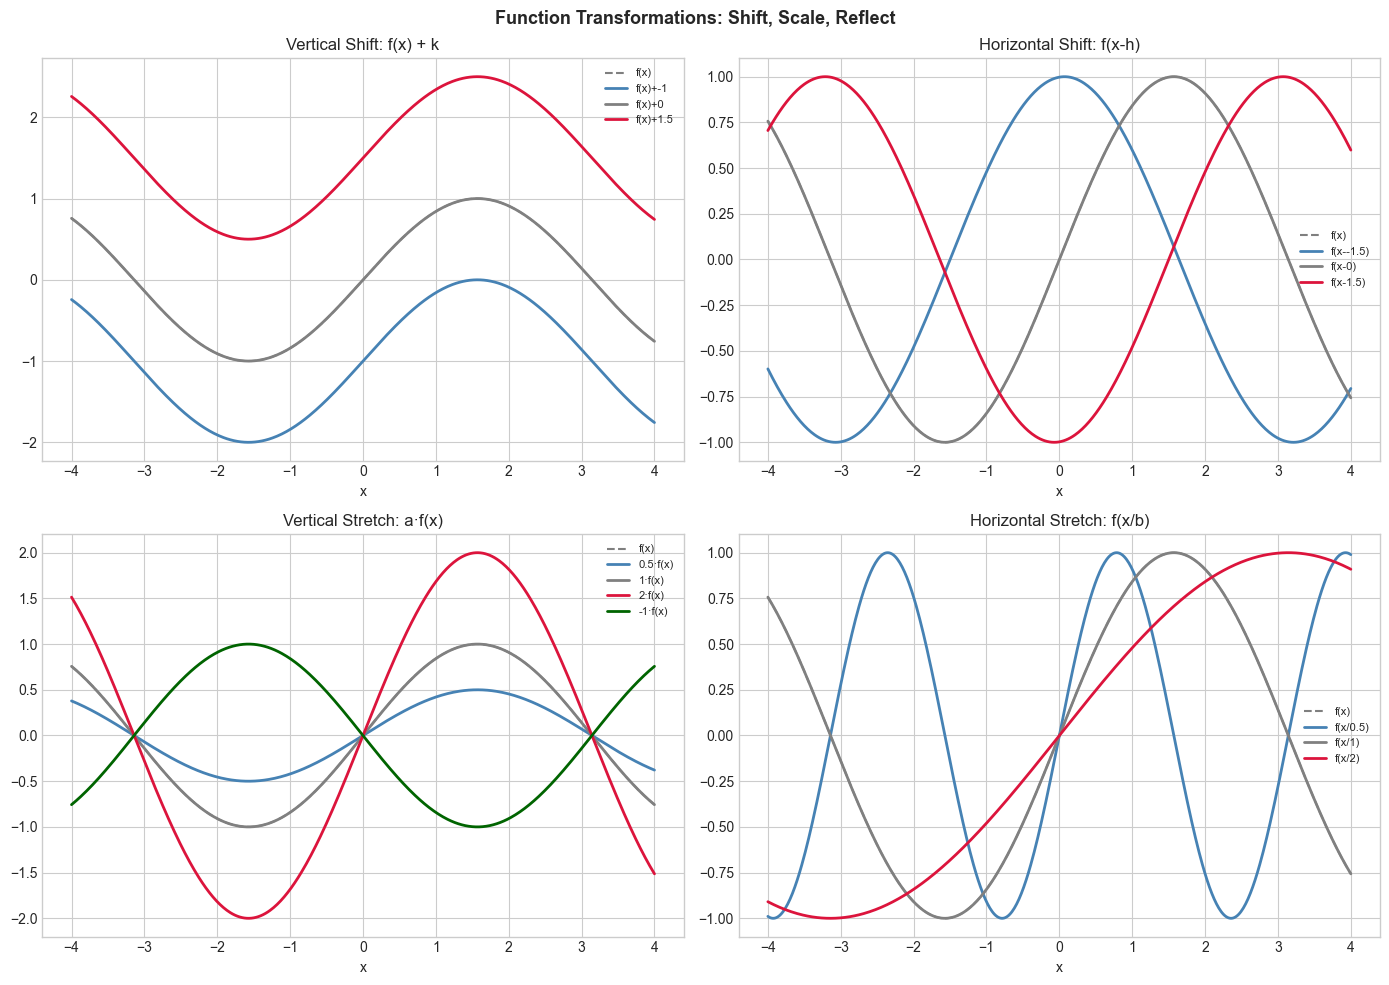

In [1]:
# --- Visualization: All four transformation types ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-4, 4, 500)
f = lambda x: np.sin(x)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Vertical shift
ax = axes[0, 0]
ax.plot(x, f(x), 'k--', linewidth=1.5, label='f(x)', alpha=0.5)
for k, color in [(-1, 'steelblue'), (0, 'gray'), (1.5, 'crimson')]:
    ax.plot(x, f(x) + k, color=color, linewidth=2, label=f'f(x)+{k}')
ax.set_title('Vertical Shift: f(x) + k'); ax.legend(fontsize=8); ax.set_xlabel('x')

# Horizontal shift
ax = axes[0, 1]
ax.plot(x, f(x), 'k--', linewidth=1.5, label='f(x)', alpha=0.5)
for h, color in [(-1.5, 'steelblue'), (0, 'gray'), (1.5, 'crimson')]:
    ax.plot(x, f(x - h), color=color, linewidth=2, label=f'f(x-{h})')
ax.set_title('Horizontal Shift: f(x-h)'); ax.legend(fontsize=8); ax.set_xlabel('x')

# Vertical stretch
ax = axes[1, 0]
ax.plot(x, f(x), 'k--', linewidth=1.5, label='f(x)', alpha=0.5)
for a, color in [(0.5, 'steelblue'), (1, 'gray'), (2, 'crimson'), (-1, 'darkgreen')]:
    ax.plot(x, a * f(x), color=color, linewidth=2, label=f'{a}·f(x)')
ax.set_title('Vertical Stretch: a·f(x)'); ax.legend(fontsize=8); ax.set_xlabel('x')

# Horizontal stretch (compression)
ax = axes[1, 1]
ax.plot(x, f(x), 'k--', linewidth=1.5, label='f(x)', alpha=0.5)
for b, color in [(0.5, 'steelblue'), (1, 'gray'), (2, 'crimson')]:
    ax.plot(x, f(x / b), color=color, linewidth=2, label=f'f(x/{b})')
ax.set_title('Horizontal Stretch: f(x/b)'); ax.legend(fontsize=8); ax.set_xlabel('x')

plt.suptitle('Function Transformations: Shift, Scale, Reflect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

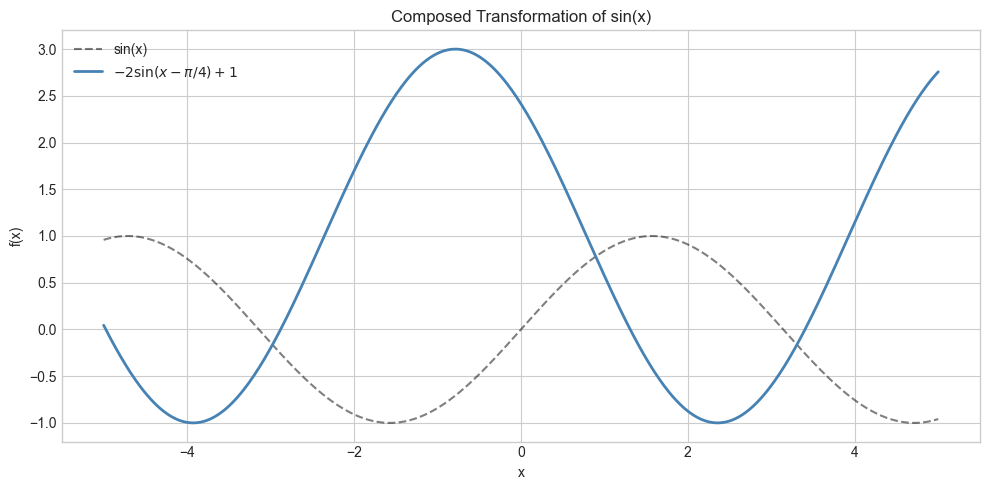

In [2]:
# --- Implementation: Transformation composer ---
import numpy as np

class TransformedFunction:
    """Apply a sequence of transformations to a base function."""
    
    def __init__(self, f):
        self.f = f
        self.transforms = []  # list of (transform_fn, label)
    
    def vertical_shift(self, k):
        self.transforms.append((lambda y, k=k: y + k, f'+ {k}'))
        return self
    
    def vertical_scale(self, a):
        self.transforms.append((lambda y, a=a: a * y, f'× {a}'))
        return self
    
    def horizontal_shift(self, h):
        self.transforms.append((lambda x, h=h: x - h, f'x→x-{h}'))
        return self
    
    def reflect_vertical(self):
        self.transforms.append((lambda y: -y, 'reflect V'))
        return self
    
    def __call__(self, x):
        # Apply input transforms, then f, then output transforms
        result = x.copy() if hasattr(x, 'copy') else x
        for fn, label in self.transforms:
            result = fn(result)
        return self.f(result) if not self.transforms else result

# Demo: transform sin(x) → -2*sin(x - π/4) + 1
import numpy as np
x = np.linspace(-5, 5, 500)
base_f = np.sin

# Manual application of transformations
def transformed(x):
    return -2 * np.sin(x - np.pi/4) + 1

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.sin(x), 'k--', linewidth=1.5, label='sin(x)', alpha=0.5)
ax.plot(x, transformed(x), color='steelblue', linewidth=2,
        label=r'$-2\sin(x - \pi/4) + 1$')
ax.set_title('Composed Transformation of sin(x)')
ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend()
plt.tight_layout(); plt.show()

---

## 6. Experiments

**Experiment 1:** Apply transformations to f(x) = e^x. What does e^(x-2) + 3 look like compared to e^x? The exponential base is preserved — only the position shifts.

**Experiment 2:** Apply horizontal and vertical stretches in different orders to f(x) = x². Does order matter? (For the same function it shouldn't, but try f(2x) + 1 vs 2f(x+1) — they are very different.)

---

## 7. Exercises

**Easy 1.** Write the transformed function g(x) = 3·f(2x - 1) + 4 for f(x) = x². Expand and simplify. What type of function is g?

**Easy 2.** If f(x) = |x|, describe the transformation that gives g(x) = -|x - 2| + 3. What is the vertex of g?

**Medium 1.** Implement `normalize_function(f, x_samples)` that transforms f so the output has mean 0 and std 1 over the given samples. This is function-level z-scoring.

**Medium 2.** Show that a horizontal shift h and vertical shift k are not interchangeable: plot f(x-2) + 1 and f(x-2+k) + k for k=1 and the same f. Explain the difference.

**Hard.** Prove algebraically that for f(x) = ax + b, f(cx + d) = a(cx+d) + b = acx + (ad+b). So the composition of linear functions is linear. Generalize: what transformations preserve the 'linear function' class?

---

## 9. Chapter Summary & Connections

- Vertical transformations (shift, scale) modify the output; horizontal transformations modify the input
- Input transformations behave counter-intuitively: f(x-h) shifts RIGHT by h
- Multiple transformations compose in order: apply from innermost to outermost
- Data normalization is a vertical transformation of f

**Forward connections:**
- ch067 (Scaling and Shifting) deepens this with parameter families
- Feature scaling in ch271 (Data and Measurement) applies these same transformations to data columns
- ch169 (Eigenvalues) interprets matrix transformations as scaling + rotation